<a href="https://colab.research.google.com/github/leahkb/Boyle_NEUR265/blob/main/homework/coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Leah Boyle
<i> Neural Data Analysis </i>
<br>
<b> March 1, 2026 </b>

In [2]:
#2. Import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [3]:
#3. Load in the patch_seq_expanded.csv and safe it to a variable

url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'
patch_seq = pd.read_csv(url)
patch_seq.head()

,ISI,Fast_Trough,Marker
0,77.337143,-49.899998,Sst
1,17.177895,-44.462498,Sst
2,48.294737,-47.350002,Sst
3,8.980000,-45.656254,Sst
4,30.315385,-50.737499,Sst


Text(0, 0.5, 'Count')

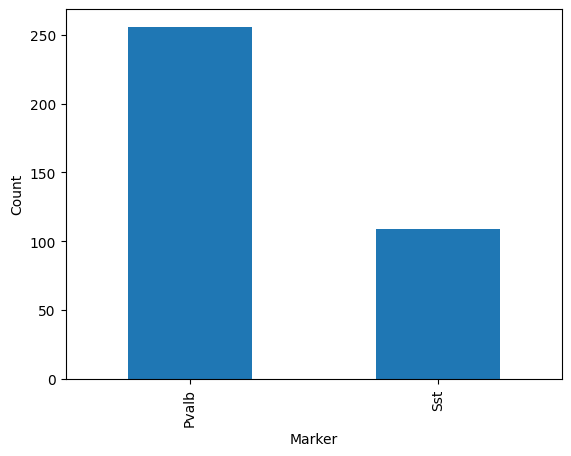

In [4]:
#4. Create a bar graph that displays the counts of each Marker column

count = patch_seq['Marker'].value_counts()
count.plot(kind='bar')
plt.xlabel("Marker")
plt.ylabel("Count")


<Axes: ylabel='count'>

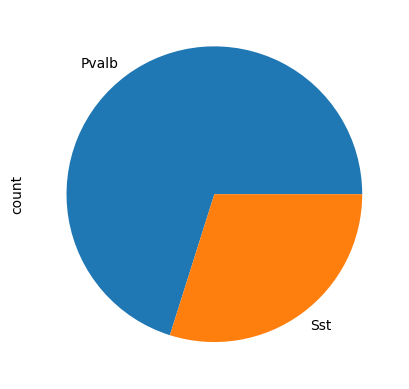

In [5]:
#5. Make step 4 into a pie chart

count.plot(kind='pie')

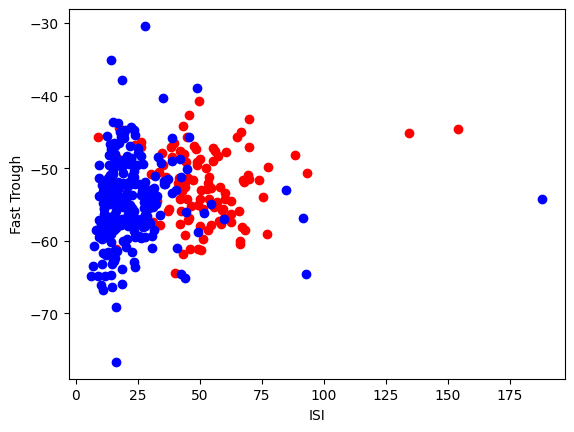

In [6]:
#6. Use a for loop to plot ISI and Fast_trough values for the two types of neurons

for i in range(len(patch_seq)):
  if patch_seq.iloc[i]['Marker'] == 'Sst':
    color = 'red'
  else :
    color = 'blue'
  plt.scatter(patch_seq.iloc[i]['ISI'], patch_seq.iloc[i]['Fast_Trough'], color=color)

plt.xlabel('ISI')
plt.ylabel('Fast Trough')

plt.show()

In [7]:
#7. Create a function that outputs the scatter plot from above

def patchScatter():
  for i in range(len(patch_seq)):
    if patch_seq.iloc[i]['Marker'] == 'Sst':
      color = 'red'
    else :
      color = 'blue'
    plt.scatter(patch_seq.iloc[i]['ISI'], patch_seq.iloc[i]['Fast_Trough'], color=color)

  plt.xlabel('ISI')
  plt.ylabel('Fast Trough')

  plt.show()

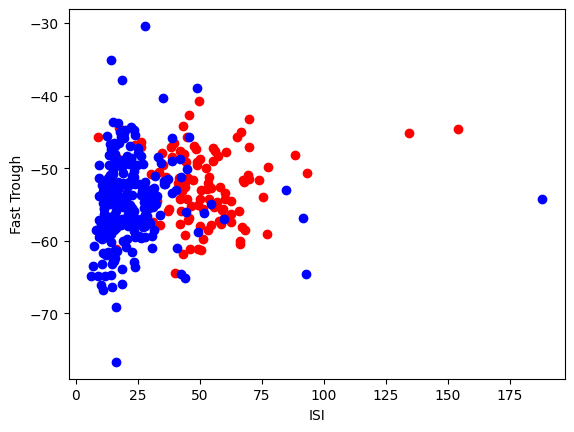

In [8]:
#7b - Run patchScatter

patchScatter()

In [20]:
#8. Return the mean, stdv, and range of fast trough values for sst and pvalb

values = patch_seq.groupby('Marker')['Fast_Trough'].describe()

print("Sst :\n")
print("mean", values.loc["Sst","mean"], "\nstandard dev", values.loc["Sst","std"], "\nrange" , values.loc["Sst","min"], "-", values.loc["Sst","max"])

print("\nPvalb :\n")
print("mean", values.loc["Pvalb","mean"], "\nstandard dev", values.loc["Pvalb","std"], "\nrange" , values.loc["Pvalb","min"], "-", values.loc["Pvalb","max"])

Sst :

mean -52.51496750614677 
standard dev 4.958102653000737 
range -64.37500763 - -40.78125381

Pvalb :

mean -54.54807350679687 
standard dev 5.870670279963872 
range -76.68750763 - -30.40625191


9. Describe the difference in means between Sst and Pvalb neurons:

The mean value for Sst neurons for fast trough is -52.5 and the mean for Pvalb is -54.5. This means that the fast trough value for Pvalb neurons is more negative and has a larger undershoot following an action potential.

In [22]:
#10. Return the skewness of the Fast Trough column for sst and pvalb neurons

patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


11. Interpret the results of your skewness test.

The value for Pvalb neurons = 0.195 < 0.5 and > -0.5 which indicates a normal distribution.

The value for Sst neurons = 0.00125 < 0.5 and > -0.5 which indicates a normal distribution


In [23]:
#12. Get the skew for the ISI column

patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


13. Interpret the results of your skewness test for ISI.  

The value for Pvalb neurons = 5.59 > 0.5  which indicates a skewed distribution.

The value for Sst neurons = 1.86 > 0.5  which indicates a skewed distribution


In [29]:
#14. Perform a t-test to see if our fast-trough values and ISI values differ between neuron types

sst_neurons = patch_seq[patch_seq['Marker']=='Sst']
pvalb_neurons = patch_seq[patch_seq['Marker']=='Pvalb']

print(stats.ttest_ind(sst_neurons['Fast_Trough'], pvalb_neurons['Fast_Trough']))



TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))


15. The results from the Fast Trough t test between Sst and Pvalb neurons show that the two sets of values differ significantly because the pvalue is 0.0016 < 0.05. This means that the undershoot voltage significantly differs between the groups.

In [30]:
#16. Repeat the t test for ISI values

print(stats.ttest_ind(sst_neurons['ISI'], pvalb_neurons['ISI']))

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))


17. When performing a t-test for ISI values between Pvalb and Sst neurons, I get nan (not a number). This likely means that the ISI data values are not always available and cannot be passed into the ttest function.

In [38]:
#Some values are NAN
print(patch_seq[patch_seq['ISI'].isna()])


     ISI  Fast_Trough Marker
136  NaN   -54.625000  Pvalb
170  NaN   -60.468754  Pvalb
190  NaN   -57.750000  Pvalb
218  NaN   -52.718750  Pvalb
283  NaN   -53.625004  Pvalb
284  NaN   -62.312504  Pvalb
298  NaN   -68.562500  Pvalb
306  NaN   -47.656254  Pvalb
317  NaN   -50.187504  Pvalb
